<a href="https://colab.research.google.com/github/Safayat777/my_new/blob/main/EfficientnetV2B3%2Btransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install -q tensorflow opencv-python

In [10]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [11]:
train_path = "/content/drive/MyDrive/DataSet/Train"
test_path  = "/content/drive/MyDrive/DataSet/Test"
IMG_SIZE = 300
BATCH_SIZE = 32

In [12]:
def clahe_fn(img):
    img = img.numpy().astype(np.uint8)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return img.astype(np.float32)

In [25]:
def tf_clahe(img, label):
    # Apply clahe_fn to each image in the batch using tf.map_fn
    # clahe_fn processes a single image, so tf.map_fn helps apply it across the batch.
    processed_img_batch = tf.map_fn(
        lambda x: tf.py_function(clahe_fn, [x], [tf.float32])[0], # Extract the tensor from the list returned by tf.py_function
        img,
        fn_output_signature=tf.TensorSpec(shape=[IMG_SIZE, IMG_SIZE, 3], dtype=tf.float32)
    )
    # The batch dimension is preserved by tf.map_fn.
    # Use tf.ensure_shape to explicitly set the static shape for Keras, including the dynamic batch size.
    processed_img_batch = tf.ensure_shape(processed_img_batch, [None, IMG_SIZE, IMG_SIZE, 3])
    return processed_img_batch, label

In [26]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(tf_clahe).prefetch(AUTOTUNE)
test_ds = test_ds.map(tf_clahe).prefetch(AUTOTUNE)

Found 6659 files belonging to 2 classes.
Found 2233 files belonging to 2 classes.


In [27]:
def cbam_block(x, ratio=8):
    channels = x.shape[-1]

    # Channel Attention
    avg = GlobalAveragePooling2D()(x)
    maxp = GlobalMaxPooling2D()(x)

    shared_dense1 = Dense(channels // ratio, activation='relu')
    shared_dense2 = Dense(channels)

    avg = shared_dense1(avg)
    avg = shared_dense2(avg)

    maxp = shared_dense1(maxp)
    maxp = shared_dense2(maxp)

    channel = Activation('sigmoid')(Add()([avg, maxp]))
    channel = Reshape((1,1,channels))(channel)

    x = Multiply()([x, channel])

    # Spatial Attention
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    spatial = Concatenate()([avg_pool, max_pool])
    spatial = Conv2D(1, 7, padding='same', activation='sigmoid')(spatial)

    x = Multiply()([x, spatial])

    return x

In [28]:
def transformer_block(x, num_heads=4, key_dim=64, ff_dim=256):
    # Layer Norm 1
    x1 = LayerNormalization()(x)

    # Multi-Head Attention
    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim
    )(x1, x1)

    x2 = Add()([x, attn])

    # Layer Norm 2
    x3 = LayerNormalization()(x2)

    # Feed Forward Network
    ff = Dense(ff_dim, activation='relu')(x3)
    ff = Dense(x.shape[-1])(ff)

    out = Add()([x2, ff])

    return out

In [29]:
base_model = EfficientNetV2B3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)

# CBAM Attention
x = cbam_block(x)

# Convert feature map to sequence for Transformer
shape = tf.keras.backend.int_shape(x)
x = Reshape((shape[1]*shape[2], shape[3]))(x)

# Transformer Encoder
x = transformer_block(x)
x = transformer_block(x)

# Back to spatial representation
x = Dense(shape[3])(x)
x = Reshape((shape[1], shape[2], shape[3]))(x)

# Global Pooling
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b3   │ (None, 10, 10,    │ 12,930,622 │ input_layer_5[0]… │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetv2-b… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1536)      │          0 │ efficientnetv2-b… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 192)       │    295,104 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1536)      │    296,448 │ dense_12[0][0],   │
│                     │                   │            │ dense_12[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 1536)      │          0 │ dense_13[0][0],   │
│                     │                   │            │ dense_13[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1536)      │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1,      │          0 │ activation_2[0][… │
│                     │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 10, 10,    │          0 │ efficientnetv2-b… │
│ (Multiply)          │ 1536)             │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 10, 10, 1) │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 10, 10, 1) │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 10, 10, 2) │          0 │ lambda_2[0][0],   │
│ (Concatenate)       │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 10, 10, 1) │         99 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 10, 10,    │          0 │ multiply_3[0][0], │
│ (Multiply)          │ 1536)             │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 100, 1536) │          0 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 1536) │      3,072 │ reshape_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 1536) │  1,575,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat

 Total params: 21,481,058 (81.94 MB)

 Trainable params: 8,547,364 (32.61 MB)

 Non-trainable params: 12,933,694 (49.34 MB)

In [30]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    ModelCheckpoint(
        "best_hybrid_model.keras",
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [32]:
history1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3248s 15s/step - accuracy: 0.9236 - loss: 0.2021 - val_accuracy: 0.9136 - val_loss: 0.2745 - learning_rate: 1.0000e-04
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3265s 15s/step - accuracy: 0.9719 - loss: 0.0798 - val_accuracy: 0.9301 - val_loss: 0.2582 - learning_rate: 1.0000e-04
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3121s 15s/step - accuracy: 0.9794 - loss: 0.0569 - val_accuracy: 0.9440 - val_loss: 0.1613 - learning_rate: 1.0000e-04
Epoch 4/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3121s 15s/step - accuracy: 0.9868 - loss: 0.0403 - val_accuracy: 0.9337 - val_loss: 0.2559 - learning_rate: 1.0000e-04
Epoch 5/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 3044s 15s/step - accuracy: 0.9851 - loss: 0.0463 - val_accuracy: 0.9481 - val_loss: 0.1809 - learning_rate: 1.0000e-04


In [33]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

70/70 ━━━━━━━━━━━━━━━━━━━━ 543s 8s/step - accuracy: 0.9440 - loss: 0.1613
Test Accuracy: 0.9440215229988098


In [34]:
y_true, y_pred, y_score = [], [], []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int))
    y_score.extend(preds.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━

In [35]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.93      0.94      1109
         1.0       0.93      0.96      0.95      1124

    accuracy                           0.94      2233
   macro avg       0.94      0.94      0.94      2233
weighted avg       0.94      0.94      0.94      2233



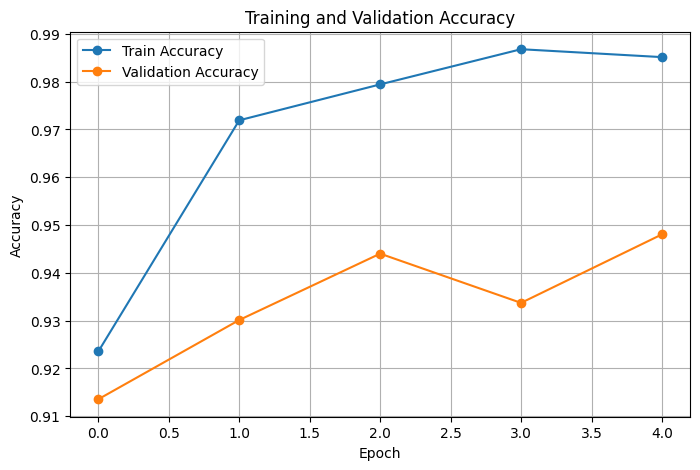

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history1.history['accuracy'], marker='o')
plt.plot(history1.history['val_accuracy'], marker='o')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy','Validation Accuracy'])
plt.grid(True)

plt.show()

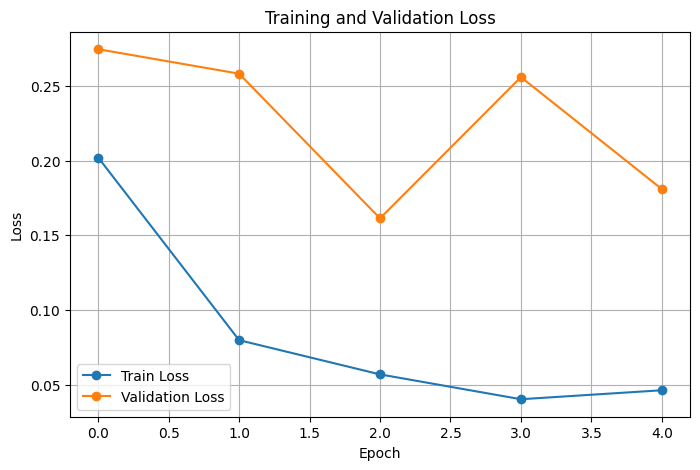

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history1.history['loss'], marker='o')
plt.plot(history1.history['val_loss'], marker='o')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss','Validation Loss'])
plt.grid(True)

plt.show()

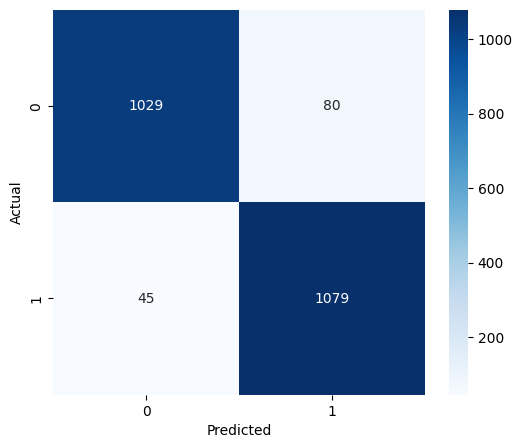

In [39]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

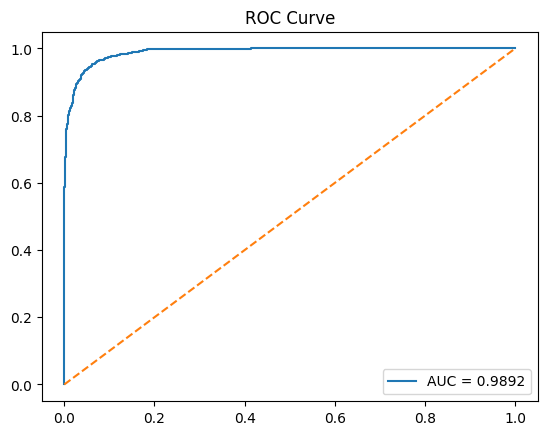

AUC: 0.9892428175811623


In [44]:
fpr, tpr, _ = roc_curve(y_true, y_score)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

print("AUC:", auc_score)